Deep Learning Course Project - Chest X-Ray Images (Pneumonia)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


Load and Preprocess the data

In [5]:
import os

# Define base directory
BASE_DIR = os.path.join(path, 'chest_xray')

print(f"Contents of {BASE_DIR}: {os.listdir(BASE_DIR)}")

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

print(f"Train directory contents: {os.listdir(TRAIN_DIR)}")
print(f"Validation directory contents: {os.listdir(VAL_DIR)}")
print(f"Test directory contents: {os.listdir(TEST_DIR)}")

Contents of /kaggle/input/chest-xray-pneumonia/chest_xray: ['chest_xray', '__MACOSX', 'val', 'test', 'train']
Train directory contents: ['PNEUMONIA', 'NORMAL']
Validation directory contents: ['PNEUMONIA', 'NORMAL']
Test directory contents: ['PNEUMONIA', 'NORMAL']


In [6]:
# Define image transformations
IMAGE_SIZE = 224 # Standard input size for many pre-trained models

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet standards
])

test_val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=test_val_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_val_transforms)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

# Create data loaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Data loaders created successfully.")

Number of training samples: 5216
Number of validation samples: 16
Number of test samples: 624
Data loaders created successfully.


Visualize Images

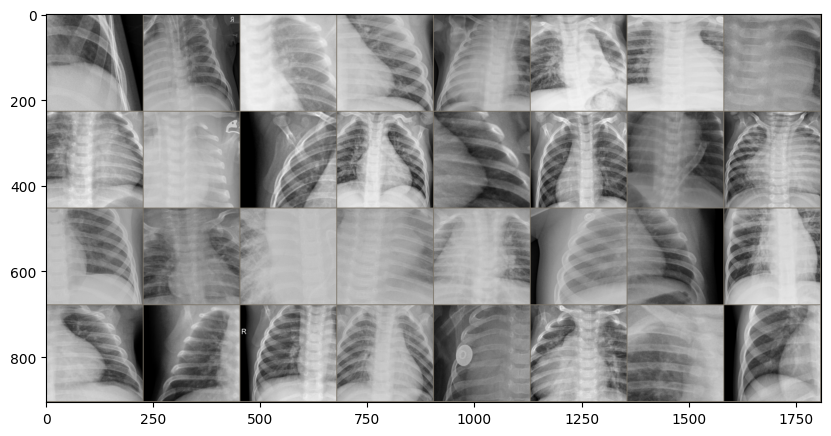

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)


# Get some training data
inputs, classes = next(iter(train_loader))

# Make a grid from data
out = torchvision.utils.make_grid(inputs)

plt.figure(figsize=(10,10))
imshow(out, title=[train_dataset.classes[x] for x in classes])
plt.show()

Train RNN model on data

In [12]:
import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers  # Corrected typo: changed num_layer to num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size, channels, height, width = x.size()

        x = x.view(batch_size, height, channels * width)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.rnn(x, h0)

        out = self.fc(out[:, -1, :])
        return out

print("SimpleRNN model defined.")

SimpleRNN model defined.


In [13]:
import torch
import torch.optim as optim
import torch.nn.functional as F

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Hyperparameters
NUM_CLASSES = len(train_dataset.classes) # 2 classes: normal, pneumonia
INPUT_SIZE = 3 * IMAGE_SIZE
HIDDEN_SIZE = 128
NUM_RNN_LAYERS = 2
LEARNING_RATE = 0.001
NUM_EPOCHS = 5

model = SimpleRNN(INPUT_SIZE, HIDDEN_SIZE, NUM_RNN_LAYERS, NUM_CLASSES).to(device)
print("Model instantiated:", model)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / total_train
        epoch_acc = correct_train / total_train

        print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_acc:.4f}')

        # Validation phase
        model.eval() # Set model to evaluation mode
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_running_loss / total_val
        val_acc = correct_val / total_val
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}')

    print('Finished Training')

# Start training
train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, device)

Using device: cpu
Model instantiated: SimpleRNN(
  (rnn): RNN(672, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
Epoch [1/5], Training Loss: 0.5773, Training Accuracy: 0.7310
Validation Loss: 0.9966, Validation Accuracy: 0.5000
Epoch [2/5], Training Loss: 0.5605, Training Accuracy: 0.7393
Validation Loss: 0.8236, Validation Accuracy: 0.5000
Epoch [3/5], Training Loss: 0.5561, Training Accuracy: 0.7504
Validation Loss: 0.7122, Validation Accuracy: 0.5000
Epoch [4/5], Training Loss: 0.5482, Training Accuracy: 0.7431
Validation Loss: 0.9492, Validation Accuracy: 0.5000
Epoch [5/5], Training Loss: 0.5467, Training Accuracy: 0.7414
Validation Loss: 0.8881, Validation Accuracy: 0.5000
Finished Training


In [14]:
model.eval() # Set model to evaluation mode

test_running_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_loss = test_running_loss / total_test
test_acc = correct_test / total_test
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')


Test Loss: 0.6991, Test Accuracy: 0.6250


The RNN model correctly classified 62.5% of the images in the test set.

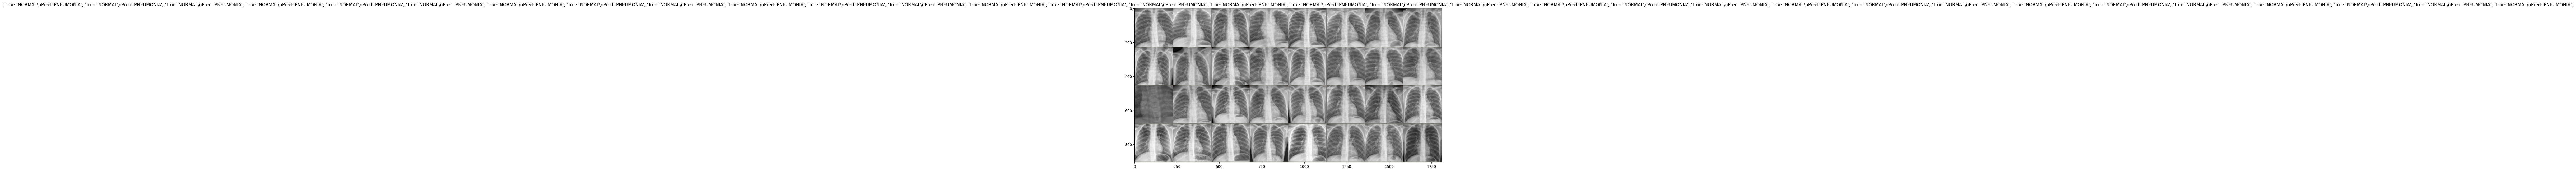

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move images to the device
images = images.to(device)
labels = labels.to(device)

# Make predictions
model.eval() # Set model to evaluation mode
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Map class indices to class names
class_names = train_dataset.classes
true_labels = [class_names[label] for label in labels]
predicted_labels = [class_names[pred] for pred in predicted]

# Plot the images with true and predicted labels
out = torchvision.utils.make_grid(images.cpu())
plt.figure(figsize=(15, 10))
imshow(out, title=[f'True: {true}\nPred: {pred}' for true, pred in zip(true_labels, predicted_labels)])
plt.show()

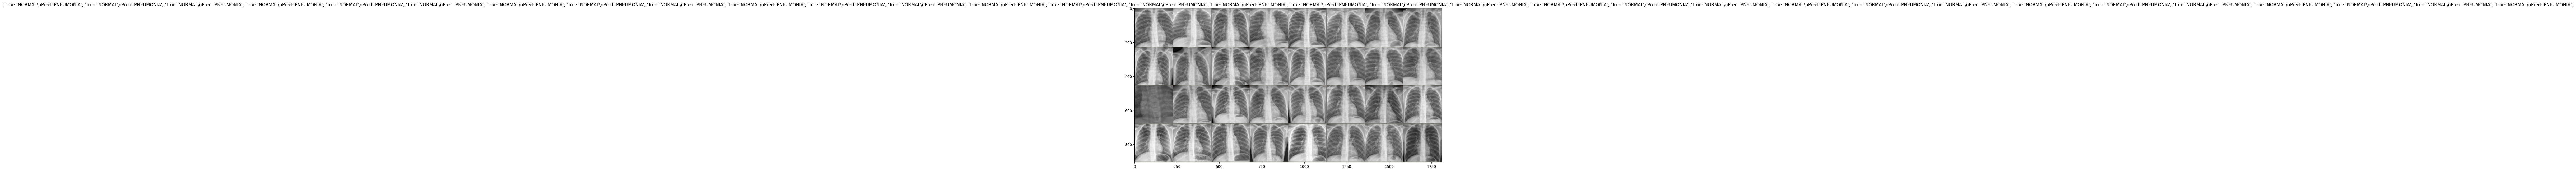

In [17]:
# Plot the images with misclassified labels

# Find misclassified images
misclassified_indices = (predicted != labels).nonzero(as_tuple=True)[0]

if len(misclassified_indices) > 0:
    # Filter images and labels for misclassified ones
    misclassified_images = images[misclassified_indices]
    misclassified_true_labels = [true_labels[i] for i in misclassified_indices]
    misclassified_predicted_labels = [predicted_labels[i] for i in misclassified_indices]

    # Make a grid from misclassified images
    out_misclassified = torchvision.utils.make_grid(misclassified_images.cpu())

    plt.figure(figsize=(15, 10))
    imshow(out_misclassified, title=[f'True: {true}\nPred: {pred}' for true, pred in zip(misclassified_true_labels, misclassified_predicted_labels)])
    plt.show()
else:
    print("No misclassified images found in this batch.")

CNN Architecture

In [18]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # Input: 3 channels (RGB), Output: 32 channels
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Fully connected layer requires calculating input features based on IMAGE_SIZE
        # Example calculation for IMAGE_SIZE=224 after 3 pooling layers:
        # 224 -> (pool) 112 -> (pool) 56 -> (pool) 28
        # So, the input to the first FC layer will be 128 * (224 / 2^3)^2 = 128 * 28 * 28
        self.fc1 = nn.Linear(128 * (IMAGE_SIZE // (2**3)) * (IMAGE_SIZE // (2**3)), 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Conv1 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x))) # Conv2 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv3(x))) # Conv3 -> ReLU -> Pool

        # Flatten the feature maps for the fully connected layers
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("SimpleCNN model architecture defined.")

SimpleCNN model architecture defined.


In [19]:
cnn_model = SimpleCNN(NUM_CLASSES).to(device)
print("CNN Model instantiated:", cnn_model)

# Loss and optimizer for CNN
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)

# Start training CNN
print("\nStarting CNN model training...")
train_model(cnn_model, train_loader, val_loader, cnn_criterion, cnn_optimizer, NUM_EPOCHS, device)

CNN Model instantiated: SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)

Starting CNN model training...
Epoch [1/5], Training Loss: 0.5368, Training Accuracy: 0.7847
Validation Loss: 0.8024, Validation Accuracy: 0.6250
Epoch [2/5], Training Loss: 0.3543, Training Accuracy: 0.8499
Validation Loss: 1.2206, Validation Accuracy: 0.6250
Epoch [3/5], Training Loss: 0.3381, Training Accuracy: 0.8537
Validation Loss: 0.8970, Validation Accuracy: 0.6875
Epoch [4/5], Training Loss: 0.3197, Training Accuracy: 0.8620
Validation Loss: 0.6355, Validation Accuracy: 0.6875
Epoch [5/5], Training Loss: 0.

### Evaluate the CNN Model

In [20]:
cnn_model.eval() # Set model to evaluation mode

cnn_test_running_loss = 0.0
cnn_correct_test = 0
cnn_total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = cnn_model(images)
        loss = cnn_criterion(outputs, labels)
        cnn_test_running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        cnn_total_test += labels.size(0)
        cnn_correct_test += (predicted == labels).sum().item()

cnn_test_loss = cnn_test_running_loss / cnn_total_test
cnn_test_acc = cnn_correct_test / cnn_total_test
print(f'CNN Test Loss: {cnn_test_loss:.4f}, CNN Test Accuracy: {cnn_test_acc:.4f}')

CNN Test Loss: 0.5021, CNN Test Accuracy: 0.8045


### Visualize CNN Predictions

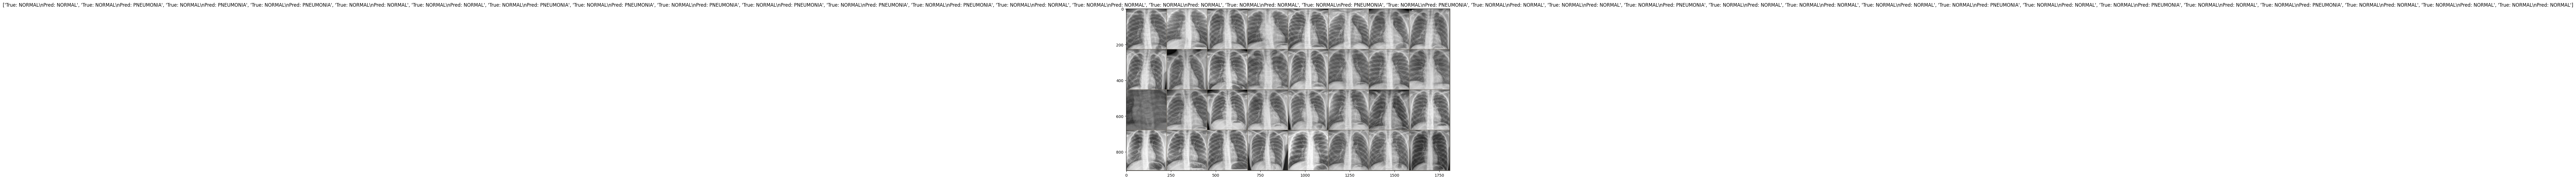

In [21]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

images = images.to(device)
labels = labels.to(device)

cnn_model.eval()
with torch.no_grad():
    outputs = cnn_model(images)
    _, predicted = torch.max(outputs, 1)

class_names = train_dataset.classes
true_labels_cnn = [class_names[label] for label in labels]
predicted_labels_cnn = [class_names[pred] for pred in predicted]

out_cnn = torchvision.utils.make_grid(images.cpu())
plt.figure(figsize=(15, 10))
imshow(out_cnn, title=[f'True: {true}\nPred: {pred}' for true, pred in zip(true_labels_cnn, predicted_labels_cnn)])
plt.show()

### Visualize Misclassified Images by CNN

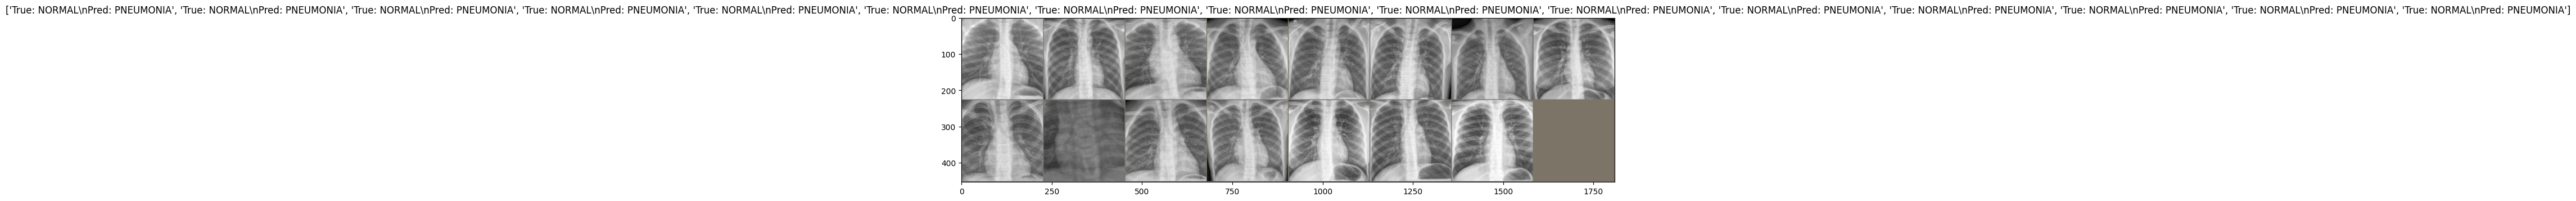

In [22]:
misclassified_indices_cnn = (predicted != labels).nonzero(as_tuple=True)[0]

if len(misclassified_indices_cnn) > 0:
    misclassified_images_cnn = images[misclassified_indices_cnn]
    misclassified_true_labels_cnn = [true_labels_cnn[i] for i in misclassified_indices_cnn]
    misclassified_predicted_labels_cnn = [predicted_labels_cnn[i] for i in misclassified_indices_cnn]

    out_misclassified_cnn = torchvision.utils.make_grid(misclassified_images_cnn.cpu())

    plt.figure(figsize=(15, 10))
    imshow(out_misclassified_cnn, title=[f'True: {true}\nPred: {pred}' for true, pred in zip(misclassified_true_labels_cnn, misclassified_predicted_labels_cnn)])
    plt.show()
else:
    print("No misclassified images found in this batch by the CNN model.")